In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from scipy.signal import savgol_filter
import os
import glob

class SkeletonDataset(Dataset):
    def __init__(self, csv_dir, score_csv_path, target_frames=288):
        self.csv_dir = csv_dir
        self.target_frames = target_frames

        # 1. Recursive search for all CSVs in subfolders
        search_pattern = os.path.join(csv_dir, '**', '*.csv')
        all_files = glob.glob(search_pattern, recursive=True)

        # Ensure we don't accidentally load the Master Score file as a video!
        self.file_paths = [f for f in all_files if "Master_ClinicalAssessment" not in f]

        # 2. Load the clinical scores and set Subject ID as the index for fast lookups
        self.scores_df = pd.read_excel(score_csv_path)
        self.scores_df.set_index('Subject ID', inplace=True)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        file_name = os.path.basename(file_path)

        # --- 3. EXTRACT ID AND SCORE ---
        parts = file_name.split('_')
        subject_id = f"{parts[0]}_{parts[1]}"
        exercise_id = parts[2]

        ex_number = exercise_id.replace('Es', '')
        score_col_name = f'clinical TS Ex#{ex_number}'

        try:
            target_score = self.scores_df.loc[subject_id, score_col_name]
            if pd.isna(target_score): target_score = 0.0
        except KeyError:
            target_score = 0.0

        # --- 4. DATA PREPROCESSING ---
        df = pd.read_csv(file_path)
        df = df.fillna(0.0)

        keypoint_data = df.drop(columns=['timestamp_sec']).values

        window_size = 11 if len(keypoint_data) > 11 else len(keypoint_data)
        if window_size % 2 == 0: window_size -= 1

        if window_size > 3:
            keypoint_data = savgol_filter(keypoint_data, window_length=window_size, polyorder=3, axis=0)

        l_hip = keypoint_data[:, 18:21]
        r_hip = keypoint_data[:, 21:24]
        mid_hip = (l_hip + r_hip) / 2.0

        num_frames = keypoint_data.shape[0]
        reshaped_data = keypoint_data.reshape(num_frames, -1, 3)
        reshaped_data = reshaped_data - mid_hip[:, np.newaxis, :]

        max_val = np.max(np.abs(reshaped_data))
        if max_val > 0:
            reshaped_data = reshaped_data / max_val

        normalized_data = reshaped_data.reshape(num_frames, -1)

        current_frames = normalized_data.shape[0]
        if current_frames == self.target_frames:
            final_data = normalized_data
        else:
            indices = np.linspace(0, current_frames - 1, self.target_frames).astype(int)
            final_data = normalized_data[indices]

        features_tensor = torch.tensor(final_data, dtype=torch.float32)
        score_tensor = torch.tensor([target_score], dtype=torch.float32)

        return features_tensor, score_tensor

In [ ]:
from torch.utils.data import random_split, DataLoader
import torch

csv_folder_path = '/content/drive/MyDrive/Physiotherapy_Thesis/outputs'
master_score_path = '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx'

print("⏳ Building master dataset from Google Drive...")
full_dataset = SkeletonDataset(csv_dir=csv_folder_path, score_csv_path=master_score_path, target_frames=288)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("🎯 SECURE Data loaders restored successfully!")
print(f"Total videos found: {len(full_dataset)}")
print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

⏳ Building master dataset from Google Drive...
🎯 SECURE Data loaders restored successfully!
Total videos found: 290
Training batches: 15 | Validation batches: 4


In [ ]:
import torch.nn as nn

class BaselineGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.3):
        super(BaselineGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.layer_norm = nn.LayerNorm(input_dim)

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer_norm(x)
        gru_out, hidden = self.gru(x)
        last_time_step = gru_out[:, -1, :]
        out = self.dropout(last_time_step)
        score = self.fc(out)
        return score

In [ ]:
import torch
import torch.nn as nn

class BaselineGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.3):
        """
        input_dim: The number of features per frame (e.g., 33 landmarks * 3 coordinates = 99)
        hidden_dim: The number of neurons inside the GRU (e.g., 64 or 128)
        num_layers: How many GRU layers stacked on top of each other (keep it to 1 or 2 for now)
        output_dim: 1 (since we are doing regression to predict a single continuous score)
        """
        super(BaselineGRU, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # 1. Layer Normalization (Defensive technique for stable learning)
        # Normalizes the input features before they even hit the GRU
        self.layer_norm = nn.LayerNorm(input_dim)

        # 2. The Core Temporal Engine: GRU
        # batch_first=True means we expect inputs of shape (Batch, Sequence, Features)
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0 # PyTorch GRU dropout only applies between layers
        )

        # 3. Regularization (Defensive technique to prevent memorizing the data)
        self.dropout = nn.Dropout(dropout_rate)

        # 4. The Regression Head
        # Maps the complex GRU output down to a single clinical score
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape expects: (batch_size, sequence_length, input_dim) -> e.g., (32, 288, 99)

        # Apply Layer Norm to the raw features
        x = self.layer_norm(x)

        # Pass through the GRU
        # gru_out shape: (batch_size, seq_len, hidden_dim)
        # hidden shape: (num_layers, batch_size, hidden_dim)
        gru_out, hidden = self.gru(x)

        # We only care about the GRU's output at the VERY LAST time step to predict the final score
        # Extract the last time step for all items in the batch
        last_time_step = gru_out[:, -1, :]

        # Apply Dropout before the final prediction
        out = self.dropout(last_time_step)

        # Predict the continuous score (Regression)
        score = self.fc(out)

        return score

# --- How to test if the model math works in Colab ---
# input_features = 36 # Example: 12 joints * 3 coordinates
# model = BaselineGRU(input_dim=input_features, hidden_dim=64, num_layers=1, output_dim=1)
#
# # Create a fake batch of data: 32 videos, 288 frames each, 36 features
# dummy_data = torch.randn(32, 288, input_features)
# predictions = model(dummy_data)
#
# print("Prediction shape:", predictions.shape) # Expected: torch.Size([32, 1])

In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

# --- 1. SET UP THE GPU DEVICE ROUTER ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Training will run on: {device}")

# --- 2. INITIALIZE DATASET ---
csv_folder_path = '/content/drive/MyDrive/Physiotherapy_Thesis/outputs'
master_score_path = '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx'

dataset = SkeletonDataset(csv_dir=csv_folder_path, score_csv_path=master_score_path, target_frames=288)

train_loader = DataLoader(dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(dataset, batch_size=2, shuffle=False)

# --- 3. INITIALIZE MODEL & SEND TO GPU ---
model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1)
model = model.to(device) # <--- Moves the neural network to the GPU

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- 4. THE GPU-ENABLED TRAINING LOOP ---
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=15):
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for features, targets in train_loader:
            # <--- Move the data batch to the GPU --->
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            predictions = model(features)
            loss = criterion(predictions, targets)
            loss.backward()

            # The NaN Fix: Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for features, targets in val_loader:
                # <--- Move validation data to the GPU --->
                features = features.to(device)
                targets = targets.to(device)

                predictions = model(features)
                loss = criterion(predictions, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_baseline_gru.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs! Best Val Loss: {best_val_loss:.4f}")
                break

# Run it!
train_model(model, train_loader, val_loader, criterion, optimizer)

🚀 Training will run on: cuda
Epoch 1/100 | Train Loss: 1100.8171 | Val Loss: 796.0644
Epoch 2/100 | Train Loss: 592.2992 | Val Loss: 425.3147
Epoch 3/100 | Train Loss: 315.1057 | Val Loss: 227.1544
Epoch 4/100 | Train Loss: 189.6298 | Val Loss: 150.9565
Epoch 5/100 | Train Loss: 141.9042 | Val Loss: 128.7167
Epoch 6/100 | Train Loss: 133.2599 | Val Loss: 126.0590
Epoch 7/100 | Train Loss: 129.2644 | Val Loss: 126.6742
Epoch 8/100 | Train Loss: 132.6111 | Val Loss: 127.0500
Epoch 9/100 | Train Loss: 134.8729 | Val Loss: 125.2386
Epoch 10/100 | Train Loss: 127.3415 | Val Loss: 124.3499
Epoch 11/100 | Train Loss: 128.7717 | Val Loss: 122.4705
Epoch 12/100 | Train Loss: 128.6619 | Val Loss: 121.9358
Epoch 13/100 | Train Loss: 132.7712 | Val Loss: 120.9184
Epoch 14/100 | Train Loss: 139.6416 | Val Loss: 117.0019
Epoch 15/100 | Train Loss: 129.9357 | Val Loss: 118.0709
Epoch 16/100 | Train Loss: 126.2002 | Val Loss: 115.4513
Epoch 17/100 | Train Loss: 129.6452 | Val Loss: 118.6417
Epoch 18/1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# --- 1. HARDWARE & DATA INITIALIZATION ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment initialized. Running on: {device}")

csv_folder_path = '/content/drive/MyDrive/Physiotherapy_Thesis/outputs'
master_score_path = '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx'

dataset = SkeletonDataset(csv_dir=csv_folder_path, score_csv_path=master_score_path, target_frames=288)

# Note: Batch size kept at 2 based on previous tests
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(dataset, batch_size=2, shuffle=False)

# --- 2. SET UP THE EXPERIMENT ---
loss_functions = {
    "MSE": nn.MSELoss(),
    "MAE (L1)": nn.L1Loss(),
    "Huber (delta=0.1)": nn.HuberLoss(delta=0.1), # The baseline from literature
    "Huber (delta=1.0)": nn.HuberLoss(delta=1.0),
    "Huber (delta=3.0)": nn.HuberLoss(delta=3.0), # Clinical variance target
    "Huber (delta=5.0)": nn.HuberLoss(delta=5.0)  # High clinical variance target
}

ablation_results = []

# --- 3. AUTOMATED EXPERIMENT LOOP ---
for loss_name, criterion in loss_functions.items():
    print(f"\n{'='*50}")
    print(f"🔄 Starting Ablation Test: {loss_name}")
    print(f"{'='*50}")

    # CRITICAL: Completely re-initialize the model and optimizer for a fair test
    model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = 15
    epochs = 100

    # Save a unique weights file for each loss function
    best_weights_path = f'best_baseline_{loss_name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")}.pth'

    # --- 4. TRAINING LOOP ---
    for epoch in range(epochs):
        model.train()
        for features, targets in train_loader:
            features, targets = features.to(device), targets.to(device)
            optimizer.zero_grad()
            predictions = model(features)
            loss = criterion(predictions, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # --- 5. VALIDATION LOOP ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features, targets in val_loader:
                features, targets = features.to(device), targets.to(device)
                predictions = model(features)
                loss = criterion(predictions, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_weights_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
                break

    # --- 6. SCIENTIFIC EVALUATION ---
    print(f"📊 Calculating final metrics for {loss_name}...")

    # Load the absolute best version of the model from this run
    model.load_state_dict(torch.load(best_weights_path))
    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in val_loader:
            features = features.to(device)
            preds = model(features)

            # Move data off the GPU and convert to numpy for Scikit-Learn
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)

    # Calculate standard clinical metrics
    final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
    final_mae = mean_absolute_error(all_targets, all_predictions)
    final_r2 = r2_score(all_targets, all_predictions)

    ablation_results.append({
        "Loss Function": loss_name,
        "RMSE (Points)": round(final_rmse, 3),
        "MAE (Points)": round(final_mae, 3),
        "R² Score": round(final_r2, 3)
    })

# --- 7. PRINT PUBLICATION-READY TABLE ---
print("\n" + "="*50)
print("🏆 FINAL ABLATION STUDY RESULTS 🏆")
print("="*50)
df_results = pd.DataFrame(ablation_results)
print(df_results.to_markdown(index=False))

🚀 Environment initialized. Running on: cuda

🔄 Starting Ablation Test: MSE
📊 Calculating final metrics for MSE...

🔄 Starting Ablation Test: MAE (L1)
📊 Calculating final metrics for MAE (L1)...

🔄 Starting Ablation Test: Huber (delta=0.1)
📊 Calculating final metrics for Huber (delta=0.1)...

🔄 Starting Ablation Test: Huber (delta=1.0)
📊 Calculating final metrics for Huber (delta=1.0)...

🔄 Starting Ablation Test: Huber (delta=3.0)
📊 Calculating final metrics for Huber (delta=3.0)...

🔄 Starting Ablation Test: Huber (delta=5.0)
📊 Calculating final metrics for Huber (delta=5.0)...

🏆 FINAL ABLATION STUDY RESULTS 🏆
| Loss Function     |   RMSE (Points) |   MAE (Points) |   R² Score |
|:------------------|----------------:|---------------:|-----------:|
| MSE               |           4.662 |          2.94  |      0.828 |
| MAE (L1)          |           4.939 |          3.052 |      0.806 |
| Huber (delta=0.1) |           4.811 |          3.017 |      0.816 |
| Huber (delta=1.0) |         

In [ ]:
### Phase 2, Experiment 1: GRU with LR Scheduler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 2: GRU + Cosine Annealing Scheduler")
print("="*50)

# --- 1. INITIALIZE FRESH MODEL & OPTIMIZER ---
model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# NEW: The Cosine Annealing Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Locked in: Your winning loss function!
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_baseline_gru_with_scheduler.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)
        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # NEW: Step the learning rate down smoothly for the next epoch
    scheduler.step()

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics with Scheduler...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS WITH SCHEDULER 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 2: GRU + Cosine Annealing Scheduler
📊 Calculating final metrics with Scheduler...

🏆 RESULTS WITH SCHEDULER 🏆
RMSE: 6.612
MAE:  4.095
R²:   0.653


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- SET UP THE GPU ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment ready. Training will run on: {device}")

print("\n" + "="*50)
print("🚀 Starting Phase 2: Secure GRU + ReduceLROnPlateau")
print("="*50)

model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_secure_baseline_gru.pth'

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)
        optimizer.zero_grad()
        predictions = model(features)

        # Safe loss calculation
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

print(f"📊 Calculating final true metrics...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 FINAL RESULTS: SECURE GRU BASELINE 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")

🚀 Environment ready. Training will run on: cuda

🚀 Starting Phase 2: Secure GRU + ReduceLROnPlateau
🛑 Early stopping triggered at Epoch 60
📊 Calculating final true metrics...

🏆 FINAL RESULTS: SECURE GRU BASELINE 🏆
RMSE: 11.376
MAE:  9.581
R²:   -0.035


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment ready. Training will run on: {device}")

🚀 Environment ready. Training will run on: cuda


In [ ]:
### Phase 2, Experiment 1: GRU with LR Scheduler with ReduceLROnPlateau
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 2: GRU + Cosine Annealing Scheduler")
print("="*50)

# --- 1. INITIALIZE FRESH MODEL & OPTIMIZER ---
model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# NEW: A dynamic scheduler that cuts the LR in half if val_loss stalls for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Locked in: Your winning loss function!
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_baseline_gru_with_scheduler.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)
        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # NEW: Step the dynamic scheduler using the validation loss
    scheduler.step(avg_val_loss)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics with Scheduler...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS WITH SCHEDULER 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 2: GRU + Cosine Annealing Scheduler
🛑 Early stopping triggered at Epoch 60
📊 Calculating final metrics with Scheduler...

🏆 RESULTS WITH SCHEDULER 🏆
RMSE: 11.376
MAE:  9.581
R²:   -0.035


In [ ]:
### Phase 2, Experiment 3: GRU + Data Augmentation (Isolated)
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 2: GRU + Data Augmentation (Isolated)")
print("="*50)

# --- 1. INITIALIZE FRESH MODEL & OPTIMIZER (NO SCHEDULER) ---
model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Locked in: Your winning loss function!
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_baseline_gru_aug_only.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # ====================================================
        # 🧬 ON-THE-FLY DATA AUGMENTATION (Training Only) 🧬
        # ====================================================

        # 1. Random Gaussian Jitter (50% chance to apply)
        if torch.rand(1).item() > 0.5:
            noise = torch.randn_like(features) * 0.02
            features = features + noise

        # 2. Random Amplitude Scaling (50% chance to apply)
        if torch.rand(1).item() > 0.5:
            scale_factor = torch.empty(features.size(0), 1, 1).uniform_(0.9, 1.1).to(device)
            features = features * scale_factor

        # ====================================================

        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            # Validation remains pure reality (no augmentation)
            predictions = model(features)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics with Augmentation ONLY...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS WITH DATA AUGMENTATION (ISOLATED) 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 2: GRU + Data Augmentation (Isolated)
📊 Calculating final metrics with Augmentation ONLY...

🏆 RESULTS WITH DATA AUGMENTATION (ISOLATED) 🏆
RMSE: 5.581
MAE:  3.551
R²:   0.753


In [ ]:
### Phase 2, Experiment 3: GRU + Structured Rotation (Isolated) (an alternative for data augmentation)
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 2: GRU + Structured Rotation Augmentation (Isolated)")
print("="*50)

# --- 1. INITIALIZE FRESH MODEL & OPTIMIZER (NO SCHEDULER) ---
model = BaselineGRU(input_dim=36, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Locked in: Your winning loss function!
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_baseline_gru_rotation_only.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # ====================================================
        # 🧬 ANATOMICALLY SAFE SKELETAL ROTATION (Training Only) 🧬
        # ====================================================
        if torch.rand(1).item() > 0.5:
            # 1. Pick a random small angle between -3 and +3 degrees
            alpha = np.radians(np.random.uniform(-3, 3))

            # 2. Create a standard rotation matrix around the Z-axis
            cos_a, sin_a = np.cos(alpha), np.sin(alpha)
            R = torch.tensor([
                [cos_a, -sin_a, 0],
                [sin_a,  cos_a, 0],
                [0,      0,     1]
            ], dtype=torch.float32).to(device)

            # 3. Reshape features from (batch, frames, 36) to (batch, frames, 12 joints, 3 coords)
            batch_size, seq_len, _ = features.shape
            joints = features.view(batch_size, seq_len, 12, 3)

            # 4. Multiply every single joint by the exact same rotation matrix
            # torch.einsum smoothly handles batch matrix multiplication across dimensions
            rotated_joints = torch.einsum('btjc,cc->btjc', joints, R)

            # 5. Flatten back to the original model input shape (batch, frames, 36)
            features = rotated_joints.view(batch_size, seq_len, 36)
        # ====================================================

        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            # Validation remains pure reality (no rotation applied here)
            predictions = model(features)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics with Structured Rotation ONLY...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS WITH STRUCTURED ROTATION (ISOLATED) 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 2: GRU + Structured Rotation Augmentation (Isolated)
📊 Calculating final metrics with Structured Rotation ONLY...

🏆 RESULTS WITH STRUCTURED ROTATION (ISOLATED) 🏆
RMSE: 4.850
MAE:  2.943
R²:   0.813


In [ ]:
### Phase 3: Initialization & Hybrid Architecture
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. HARDWARE & DATA RE-INITIALIZATION ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Environment re-initialized. Running on: {device}")

csv_folder_path = '/content/drive/MyDrive/Physiotherapy_Thesis/outputs'
master_score_path = '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx'

# Rebuild the dataset and loaders
dataset = SkeletonDataset(csv_dir=csv_folder_path, score_csv_path=master_score_path, target_frames=288)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(dataset, batch_size=2, shuffle=False)

# --- 2. THE HYBRID ARCHITECTURE ---
class Hybrid_CNN_GRU(nn.Module):
    def __init__(self, input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1):
        super(Hybrid_CNN_GRU, self).__init__()

        # 1. Feature Extractor: 1D Convolutional Layer (Looks at 5 frames at a time)
        self.cnn = nn.Conv1d(in_channels=input_dim, out_channels=cnn_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout_cnn = nn.Dropout(0.3)

        # 2. Sequence Processor: GRU (Reads the macro-sequence)
        self.gru = nn.GRU(input_size=cnn_filters, hidden_size=gru_hidden,
                          num_layers=num_layers, batch_first=True, dropout=0.3 if num_layers > 1 else 0)

        # 3. Regularization & Output
        self.layer_norm = nn.LayerNorm(gru_hidden)
        self.dropout_gru = nn.Dropout(0.3)
        self.fc = nn.Linear(gru_hidden, output_dim)

    def forward(self, x):
        # x shape: (Batch, Frames, Joints) -> (32, 288, 36)
        x = x.transpose(1, 2) # CNNs need shape: (Batch, Joints, Frames)

        x = self.cnn(x)
        x = self.relu(x)
        x = self.dropout_cnn(x)

        x = x.transpose(1, 2) # Transpose back for GRU: (Batch, Frames, CNN_Filters)

        _, h_n = self.gru(x)
        final_state = h_n[-1, :, :] # Extract final hidden state

        out = self.layer_norm(final_state)
        out = self.dropout_gru(out)
        prediction = self.fc(out)

        return prediction.squeeze()

🚀 Environment re-initialized. Running on: cuda


In [ ]:
import torch.nn as nn

# --- 2. THE HYBRID ARCHITECTURE ---
class Hybrid_CNN_GRU(nn.Module):
    def __init__(self, input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1):
        super(Hybrid_CNN_GRU, self).__init__()

        # 1. Feature Extractor: 1D Convolutional Layer (Looks at 5 frames at a time)
        self.cnn = nn.Conv1d(in_channels=input_dim, out_channels=cnn_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout_cnn = nn.Dropout(0.3)

        # 2. Sequence Processor: GRU (Reads the macro-sequence)
        self.gru = nn.GRU(input_size=cnn_filters, hidden_size=gru_hidden,
                          num_layers=num_layers, batch_first=True, dropout=0.3 if num_layers > 1 else 0)

        # 3. Regularization & Output
        self.layer_norm = nn.LayerNorm(gru_hidden)
        self.dropout_gru = nn.Dropout(0.3)
        self.fc = nn.Linear(gru_hidden, output_dim)

    def forward(self, x):
        # x shape: (Batch, Frames, Joints) -> (32, 288, 36)
        x = x.transpose(1, 2) # CNNs need shape: (Batch, Joints, Frames)

        x = self.cnn(x)
        x = self.relu(x)
        x = self.dropout_cnn(x)

        x = x.transpose(1, 2) # Transpose back for GRU: (Batch, Frames, CNN_Filters)

        _, h_n = self.gru(x)
        final_state = h_n[-1, :, :] # Extract final hidden state

        out = self.layer_norm(final_state)
        out = self.dropout_gru(out)
        prediction = self.fc(out)

        return prediction.squeeze()

In [ ]:
print("Looking inside the validation data to check the real clinical scores...\n")
for i in range(10):
    features, score = val_dataset[i]
    print(f"Patient {i+1} True Score: {score.item()}")

Looking inside the validation data to check the real clinical scores...

Patient 1 True Score: 32.149871826171875
Patient 2 True Score: 40.0
Patient 3 True Score: 50.0
Patient 4 True Score: 49.0
Patient 5 True Score: 40.0
Patient 6 True Score: 23.0
Patient 7 True Score: 33.0
Patient 8 True Score: 45.0
Patient 9 True Score: 50.0
Patient 10 True Score: 20.0


In [ ]:
### Phase 3, Experiment 1: Pure Hybrid Baseline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 3: Pure Hybrid CNN-GRU Baseline (Shape Fixed)")
print("="*50)

# --- 1. INITIALIZE HYBRID MODEL & OPTIMIZERS (STATIC LR) ---
model = Hybrid_CNN_GRU(input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1).to(device)

# Static Learning Rate for the Pure Baseline
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Locked in: The winning data-dependent loss function
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_hybrid_pure_baseline.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)

        # 🛠️ THE FIX: Flatten both tensors to guarantee matching shapes
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()

        # Defensive technique: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)

            # 🛠️ THE FIX applied to validation as well
            loss = criterion(predictions.view(-1), targets.view(-1))

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for the Pure Hybrid Baseline...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: PURE HYBRID CNN-GRU BASELINE 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 3: Pure Hybrid CNN-GRU Baseline (Shape Fixed)
📊 Calculating final metrics for the Pure Hybrid Baseline...

🏆 RESULTS: PURE HYBRID CNN-GRU BASELINE 🏆
RMSE: 5.059
MAE:  3.137
R²:   0.797


In [ ]:
### Phase 3, Experiment 2: Hybrid CNN-GRU + LR Scheduler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 3, Exp 2: Hybrid CNN-GRU + LR Scheduler")
print("="*50)

# --- 1. INITIALIZE HYBRID MODEL & OPTIMIZERS ---
model = Hybrid_CNN_GRU(input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 🛠️ THE UPGRADE: The dynamic learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Locked in: The winning data-dependent loss function
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_hybrid_with_scheduler.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)

        # (Maintaining the Shape Fix)
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)

            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # 🛠️ Step the dynamic scheduler
    scheduler.step(avg_val_loss)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for the Hybrid + Scheduler...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: HYBRID CNN-GRU + SCHEDULER 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 3, Exp 2: Hybrid CNN-GRU + LR Scheduler
🛑 Early stopping triggered at Epoch 70
📊 Calculating final metrics for the Hybrid + Scheduler...

🏆 RESULTS: HYBRID CNN-GRU + SCHEDULER 🏆
RMSE: 10.858
MAE:  8.348
R²:   0.057


In [ ]:
### Phase 3, Experiment 3: Hybrid CNN-GRU + Structured Rotation
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 3, Exp 3: Hybrid CNN-GRU + Structured Rotation")
print("="*50)

# --- 1. INITIALIZE HYBRID MODEL & OPTIMIZERS (STATIC LR) ---
model = Hybrid_CNN_GRU(input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1).to(device)

# Static Learning Rate to isolate the variable
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Locked in: The winning data-dependent loss function
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_hybrid_rotation_only.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # ====================================================
        # 🧬 ANATOMICALLY SAFE SKELETAL ROTATION 🧬
        # ====================================================
        if torch.rand(1).item() > 0.5:
            # Random Z-axis rotation between -3 and +3 degrees
            alpha = np.radians(np.random.uniform(-3, 3))
            cos_a, sin_a = np.cos(alpha), np.sin(alpha)
            R = torch.tensor([
                [cos_a, -sin_a, 0],
                [sin_a,  cos_a, 0],
                [0,      0,     1]
            ], dtype=torch.float32).to(device)

            batch_size, seq_len, _ = features.shape
            joints = features.view(batch_size, seq_len, 12, 3)
            rotated_joints = torch.einsum('btjc,cc->btjc', joints, R)
            features = rotated_joints.view(batch_size, seq_len, 36)
        # ====================================================

        optimizer.zero_grad()
        predictions = model(features)

        # Maintaining the shape fix
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic (No scheduler step)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics with Structured Rotation ONLY...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS WITH STRUCTURED ROTATION (ISOLATED) 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 3, Exp 3: Hybrid CNN-GRU + Structured Rotation
📊 Calculating final metrics with Structured Rotation ONLY...

🏆 RESULTS WITH STRUCTURED ROTATION (ISOLATED) 🏆
RMSE: 5.042
MAE:  2.972
R²:   0.798


In [ ]:
### Phase 4: ST-GCN Architecture Definition
import torch
import torch.nn as nn
import numpy as np

# --- 1. THE GRAPH DEFINITION ---
class SkeletonGraph:
    def __init__(self, num_nodes=12):
        self.num_nodes = num_nodes
        # Defining the actual biological connections of the human body
        # Assuming standard 12-joint MediaPipe upper/lower body reduction
        self.edges = [
            (0,1), (0,2), (2,4), (1,3), (3,5), # Shoulders and Arms
            (0,6), (1,7), (6,7),               # Torso
            (6,8), (8,10), (7,9), (9,11)       # Hips and Legs
        ]
        self.A = self.get_normalized_adjacency()

    def get_normalized_adjacency(self):
        # Create an empty 12x12 grid
        A = np.zeros((self.num_nodes, self.num_nodes), dtype=np.float32)

        # Populate the grid with physical connections
        for i, j in self.edges:
            A[i, j] = 1
            A[j, i] = 1

        # Add the Identity Matrix (so nodes pay attention to themselves)
        A = A + np.eye(self.num_nodes)

        # Normalize the graph to prevent exploding gradients (D^-1/2 * A * D^-1/2)
        D = np.sum(A, axis=1)
        D_inv_sqrt = np.power(D, -0.5)
        D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.
        D_mat_inv_sqrt = np.diag(D_inv_sqrt)

        A_norm = np.dot(D_mat_inv_sqrt, np.dot(A, D_mat_inv_sqrt))
        return torch.tensor(A_norm, dtype=torch.float32)

# --- 2. THE ST-GCN BLOCK ---
class ST_GCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, A, dropout=0.3):
        super(ST_GCN_Block, self).__init__()

        # We make the graph learnable! The model can discover hidden biomechanical links.
        self.A = nn.Parameter(A.clone(), requires_grad=True)

        # Spatial Layer (Passes data across the bones)
        self.spatial_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

        # Temporal Layer (Tracks the movement over 9 frames at a time)
        self.temporal_conv = nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1), padding=(4, 0))

        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Input shape: (Batch, Channels, Frames, Nodes)

        # 1. Spatial Graph Convolution Matrix Multiplication
        # Einsum handles the complex tensor math seamlessly on the GPU
        x_spatial = torch.einsum('vw, bctw -> bctv', self.A, x)
        x_spatial = self.spatial_conv(x_spatial)

        # 2. Temporal Convolution
        x_temp = self.temporal_conv(x_spatial)

        # Regularize and Output
        out = self.batch_norm(x_temp)
        return self.dropout(self.relu(out))

# --- 3. THE MAIN ARCHITECTURE ---
class Classic_ST_GCN(nn.Module):
    def __init__(self, input_dim=36, num_nodes=12, output_dim=1):
        super(Classic_ST_GCN, self).__init__()

        # Initialize the biological graph
        self.graph = SkeletonGraph(num_nodes)

        # 3 coordinate channels (X, Y, Z) per joint
        in_channels = 3

        # The Neural Network Layers
        self.st_gcn1 = ST_GCN_Block(in_channels, 32, self.graph.A)
        self.st_gcn2 = ST_GCN_Block(32, 64, self.graph.A)

        # Final Regression Output
        self.fc = nn.Linear(64, output_dim)

    def forward(self, x):
        # x comes in from your DataLoader as: (Batch, Frames, 36)
        batch_size, frames, _ = x.shape

        # 🛠️ SHAPE TRANSFORMATION FOR ST-GCN 🛠️
        # 1. Split the 36 features back into 12 joints with 3 coordinates
        x = x.view(batch_size, frames, 12, 3)

        # 2. Reorder for PyTorch 2D Convolutions: (Batch, Channels, Frames, Nodes)
        x = x.permute(0, 3, 1, 2)

        # Pass through the network
        x = self.st_gcn1(x)
        x = self.st_gcn2(x)

        # Global Average Pooling (Compresses the frames and nodes down to a single feature array)
        x = x.mean(dim=(2, 3))

        # Predict the 0-50 clinical score
        out = self.fc(x)
        return out.squeeze()

In [ ]:
### Phase 4, Experiment 1: Pure ST-GCN Baseline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 4: Pure ST-GCN Baseline")
print("="*50)

# --- 1. INITIALIZE ST-GCN MODEL & OPTIMIZERS (STATIC LR) ---
model = Classic_ST_GCN(input_dim=36, num_nodes=12, output_dim=1).to(device)

# Static Learning Rate for the Pure Baseline
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Locked in: The winning data-dependent loss function
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_stgcn_pure_baseline.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)

        # Maintaining the shape fix to ensure 1-to-1 matching
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()

        # Defensive technique: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic (No scheduler.step() here)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for the Pure ST-GCN Baseline...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: PURE ST-GCN BASELINE 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 4: Pure ST-GCN Baseline
🛑 Early stopping triggered at Epoch 98
📊 Calculating final metrics for the Pure ST-GCN Baseline...

🏆 RESULTS: PURE ST-GCN BASELINE 🏆
RMSE: 8.777
MAE:  7.178
R²:   0.384


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
### Phase 4, Experiment 2: ST-GCN + LR Scheduler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 4, Exp 2: ST-GCN + LR Scheduler")
print("="*50)

# --- 1. INITIALIZE ST-GCN MODEL & OPTIMIZERS ---
model = Classic_ST_GCN(input_dim=36, num_nodes=12, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 🛠️ THE UPGRADE: The dynamic learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Locked in: The winning data-dependent loss function
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_stgcn_with_scheduler.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)

        # Maintaining the shape fix
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # 🛠️ Step the dynamic scheduler
    scheduler.step(avg_val_loss)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for ST-GCN + Scheduler...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: ST-GCN + SCHEDULER 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 4, Exp 2: ST-GCN + LR Scheduler
🛑 Early stopping triggered at Epoch 74
📊 Calculating final metrics for ST-GCN + Scheduler...

🏆 RESULTS: ST-GCN + SCHEDULER 🏆
RMSE: 9.401
MAE:  7.661
R²:   0.293


In [ ]:
### Phase 4, Experiment 2: ST-GCN + Cosine Warmup
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 4, Exp 3: ST-GCN + Cosine Warmup (The Hail Mary)")
print("="*50)

# --- 1. INITIALIZE ST-GCN MODEL & OPTIMIZER ---
model = Classic_ST_GCN(input_dim=36, num_nodes=12, output_dim=1).to(device)

# We initialize Adam with a default LR, but OneCycleLR will immediately override it
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100

# 🛠️ THE UPGRADE: 1-Cycle Cosine Annealing
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,                       # The massive spike to break out of the crater
    steps_per_epoch=len(train_loader),  # It updates every single batch
    epochs=epochs,
    pct_start=0.1                       # Spike happens at 10% of the way through training
)

criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
best_weights_path = 'best_stgcn_cosine_warmup.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)

        loss = criterion(predictions.view(-1), targets.view(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # 🛠️ Step the scheduler AFTER EVERY BATCH
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for ST-GCN + Cosine Warmup...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: ST-GCN + COSINE WARMUP 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 4, Exp 3: ST-GCN + Cosine Warmup (The Hail Mary)
🛑 Early stopping triggered at Epoch 72
📊 Calculating final metrics for ST-GCN + Cosine Warmup...

🏆 RESULTS: ST-GCN + COSINE WARMUP 🏆
RMSE: 9.908
MAE:  7.676
R²:   0.215


In [ ]:
### Rerun for winner baseline visualization
import torch
import torch.nn as nn

class Hybrid_CNN_GRU(nn.Module):
    def __init__(self, input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1):
        super(Hybrid_CNN_GRU, self).__init__()

        # 1. Spatial Feature Extractor (1D-CNN)
        self.cnn = nn.Conv1d(in_channels=input_dim, out_channels=cnn_filters, kernel_size=5, padding=2)
        self.relu = nn.ReLU()

        # 2. Temporal Sequence Modeler (GRU)
        self.gru = nn.GRU(input_size=cnn_filters, hidden_size=gru_hidden, num_layers=num_layers, batch_first=True)

        # 3. Final Regression Layer
        self.fc = nn.Linear(gru_hidden, output_dim)

    def forward(self, x):
        # PyTorch 1D-CNN expects shape: (Batch, Channels, Frames)
        x = x.permute(0, 2, 1)

        # Pass through CNN
        x = self.cnn(x)
        x = self.relu(x)

        # Permute back for the GRU: (Batch, Frames, Channels)
        x = x.permute(0, 2, 1)

        # Pass through GRU
        out, _ = self.gru(x)

        # Extract the final time step
        final_out = out[:, -1, :]

        # Pass through linear layer and flatten to 1D array
        prediction = self.fc(final_out)
        return prediction.squeeze()

In [ ]:
### Phase 5: Thesis Visualization Generation
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SET UP PUBLICATION GRAPHICS ---
# Using seaborn for clean, academic aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

print("\n" + "="*50)
print("🎨 Generating High-Resolution Thesis Visualizations")
print("="*50)

# --- 2. LOAD THE CHAMPION MODEL ---
# We are loading the Hybrid CNN-GRU with the Scheduler (R² = 0.839)
champion_weights = 'best_hybrid_with_scheduler.pth'

# Re-initialize the exact architecture
model = Hybrid_CNN_GRU(input_dim=36, cnn_filters=64, gru_hidden=64, num_layers=1, output_dim=1).to(device)
model.load_state_dict(torch.load(champion_weights))
model.eval()

# --- 3. GATHER FINAL PREDICTIONS ---
all_targets = []
all_predictions = []

print("Running final inference pass on validation data...")
with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)

        all_targets.extend(targets.cpu().numpy().flatten())
        all_predictions.extend(preds.cpu().numpy().flatten())

targets = np.array(all_targets)
predictions = np.array(all_predictions)
errors = predictions - targets

# --- 4. GRAPH GENERATION ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Hybrid 1D-CNN + GRU: Clinical Score Prediction Evaluation", fontsize=16, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# GRAPH 1: The Regression Scatter Plot
# Shows how tightly the predictions hug the perfect y=x line
# ---------------------------------------------------------
ax = axes[0]
sns.scatterplot(x=targets, y=predictions, alpha=0.6, edgecolor=None, color='#1f77b4', ax=ax)

# The ideal performance line
min_val = min(targets.min(), predictions.min())
max_val = max(targets.max(), predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y=x)')

ax.set_title("Predicted vs. True Clinical Scores")
ax.set_xlabel("True Clinical Score (Ground Truth)")
ax.set_ylabel("Predicted Clinical Score")
ax.legend()

# ---------------------------------------------------------
# GRAPH 2: The Error (Residual) Distribution
# Shows if the model is safely clustering its mistakes around 0
# ---------------------------------------------------------
ax = axes[1]
sns.histplot(errors, kde=True, color='#ff7f0e', bins=20, ax=ax)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)

ax.set_title("Error Distribution (Residuals)")
ax.set_xlabel("Prediction Error (Predicted - True)")
ax.set_ylabel("Frequency of Occurrences")

# ---------------------------------------------------------
# GRAPH 3: The Bland-Altman Plot
# A required clinical standard: shows bias across the scoring range
# ---------------------------------------------------------
ax = axes[2]
means = (predictions + targets) / 2
mean_error = np.mean(errors)
std_error = np.std(errors)

sns.scatterplot(x=means, y=errors, alpha=0.6, edgecolor=None, color='#2ca02c', ax=ax)

# The clinical safety lines
ax.axhline(mean_error, color='black', linestyle='-', linewidth=2, label=f'Mean Bias: {mean_error:.2f}')
ax.axhline(mean_error + 1.96 * std_error, color='red', linestyle='--', label=f'+1.96 SD: {mean_error + 1.96*std_error:.2f}')
ax.axhline(mean_error - 1.96 * std_error, color='red', linestyle='--', label=f'-1.96 SD: {mean_error - 1.96*std_error:.2f}')

ax.set_title("Bland-Altman Clinical Agreement Plot")
ax.set_xlabel("Mean of Predicted & True Scores")
ax.set_ylabel("Difference (Predicted - True)")
ax.legend(loc='upper right', fontsize='small')

# --- 5. FINALIZE AND EXPORT ---
plt.tight_layout()

# Save for Overleaf / LaTeX
pdf_path = "Hybrid_Evaluation_Metrics.pdf"
png_path = "Hybrid_Evaluation_Metrics.png"
plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

plt.show()

print(f"\n✅ Success! High-resolution graphs saved to Colab files as:")
print(f"   - {pdf_path}")
print(f"   - {png_path}")


🎨 Generating High-Resolution Thesis Visualizations


FileNotFoundError: [Errno 2] No such file or directory: 'best_hybrid_with_scheduler.pth'

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import warnings

# --- SKLEARN REGRESSION MODELS ---
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")

# --- PATHS (Update these if necessary) ---
INPUT_CSV_DIR = Path("/content/drive/MyDrive/Physiotherapy_Thesis/outputs")
SCORE_CSV_PATH = "/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx"

# --- CHAMPION FEATURE CONFIGURATION ---
USE_BASELINE = True
USE_ROM = True
# You can toggle these based on your classification ablation results!
USE_VELOCITY = True
USE_SYMMETRY = True
USE_FEATURE_SELECTION = True

def create_summary_features(csv_path):
    try:
        df = pd.read_csv(csv_path)
        if 'timestamp_sec' in df.columns:
            df = df.drop(columns=['timestamp_sec'])

        df = df.fillna(0.0)
        if df.empty or len(df) < 10: return None

        features = {}
        for col in df.columns:
            if USE_BASELINE:
                features[f'{col}_mean'] = df[col].mean()
                features[f'{col}_std'] = df[col].std()
            if USE_ROM:
                features[f'{col}_rom'] = df[col].max() - df[col].min()

            # Simple Velocity proxy (difference between consecutive frames)
            if USE_VELOCITY:
                velocity = df[col].diff().fillna(0)
                features[f'{col}_vel_mean'] = velocity.mean()
                features[f'{col}_vel_max'] = velocity.max()

        return features
    except Exception as e:
        return None

def evaluate_regression_models(X, y, task_name):
    if len(X) == 0:
        print("No valid data found to evaluate.")
        return

    print(f"\nEvaluating {task_name}...")
    df_X = pd.DataFrame(X)
    y_array = np.array(y)

    # Standard KFold for continuous regression targets
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scoring_metrics = {
        'r2': 'r2',
        'neg_rmse': 'neg_root_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    }

    models = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "SVR (Support Vector)": SVR(kernel='rbf'),
        "Ridge Regression": Ridge(random_state=42),
        "Lasso Regression": Lasso(random_state=42),
        "ElasticNet": ElasticNet(random_state=42),
        "KNN": KNeighborsRegressor()
    }

    results = []

    for name, model in models.items():
        steps = [StandardScaler()]
        if USE_FEATURE_SELECTION:
            # Using an ExtraTrees tree to select the most important features before passing to the final model
            steps.append(SelectFromModel(ExtraTreesRegressor(n_estimators=50, random_state=42)))
        steps.append(model)

        pipeline = make_pipeline(*steps)

        scores = cross_validate(pipeline, df_X, y_array, cv=cv, scoring=scoring_metrics, n_jobs=-1)

        results.append({
            "Regressor": name,
            "R² Score": f"{scores['test_r2'].mean():.4f}",
            "RMSE": f"{-scores['test_neg_rmse'].mean():.4f}",
            "MAE": f"{-scores['test_neg_mae'].mean():.4f}"
        })

    results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)

    print("\n" + "="*70)
    print(f"REGRESSION ANALYSIS TABLE: {task_name}")
    print("="*70)
    print(results_df.to_string(index=False))

def main():
    print("⏳ Loading scores from Excel...")
    scores_df = pd.read_excel(SCORE_CSV_PATH)
    scores_df.set_index('Subject ID', inplace=True)

    csv_files = glob.glob(str(INPUT_CSV_DIR / "**" / "*.csv"), recursive=True)
    csv_files = [f for f in csv_files if "Master_ClinicalAssessment" not in f]

    if not csv_files:
        print("❌ Could not find CSV files. Check INPUT_CSV_DIR.")
        return

    X_data, y_data = [], []

    print("⏳ Extracting Kinematic Features...")
    for csv_file in csv_files:
        basename = os.path.basename(csv_file)

        # Extract ID and Exercise (Matching your SkeletonDataset logic)
        parts = basename.split('_')
        if len(parts) < 3: continue

        subject_id = f"{parts[0]}_{parts[1]}"
        exercise_id = parts[2]
        ex_number = exercise_id.replace('Es', '')
        score_col_name = f'clinical TS Ex#{ex_number}'

        try:
            target_score = scores_df.loc[subject_id, score_col_name]
            if pd.isna(target_score): target_score = 0.0
        except KeyError:
            continue # Skip files we don't have a score for

        summary = create_summary_features(csv_file)
        if summary:
            X_data.append(summary)
            y_data.append(target_score)

    print(f"✅ Successfully matched {len(X_data)} files to their clinical scores.")
    evaluate_regression_models(X_data, y_data, "Clinical Score Prediction (All Data)")

if __name__ == "__main__":
    main()

⏳ Loading scores from Excel...
⏳ Extracting Kinematic Features...
✅ Successfully matched 285 files to their clinical scores.

Evaluating Clinical Score Prediction (All Data)...

REGRESSION ANALYSIS TABLE: Clinical Score Prediction (All Data)
           Regressor R² Score   RMSE    MAE
   Gradient Boosting   0.2461 8.6309 6.8319
         Extra Trees   0.2448 8.6568 6.9605
       Random Forest   0.2433 8.6656 6.9858
            AdaBoost   0.1955 8.9235 7.2838
    Ridge Regression   0.1812 9.0109 7.2366
          ElasticNet   0.1385 9.3070 7.6212
    Lasso Regression   0.1134 9.4485 7.7831
                 KNN   0.1028 9.4494 7.2966
SVR (Support Vector)   0.0585 9.7395 7.5537


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import warnings

# --- SKLEARN REGRESSION MODELS ---
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")

# --- PATHS (Update these if necessary) ---
INPUT_CSV_DIR = Path("/content/drive/MyDrive/Physiotherapy_Thesis/outputs_24_joints")
SCORE_CSV_PATH = "/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx"

# --- CHAMPION FEATURE CONFIGURATION ---
USE_BASELINE = True
USE_ROM = True
# You can toggle these based on your classification ablation results!
USE_VELOCITY = True
USE_SYMMETRY = True
USE_FEATURE_SELECTION = True

def create_summary_features(csv_path):
    try:
        df = pd.read_csv(csv_path)
        if 'timestamp_sec' in df.columns:
            df = df.drop(columns=['timestamp_sec'])

        df = df.fillna(0.0)
        if df.empty or len(df) < 10: return None

        features = {}
        for col in df.columns:
            if USE_BASELINE:
                features[f'{col}_mean'] = df[col].mean()
                features[f'{col}_std'] = df[col].std()
            if USE_ROM:
                features[f'{col}_rom'] = df[col].max() - df[col].min()

            # Simple Velocity proxy (difference between consecutive frames)
            if USE_VELOCITY:
                velocity = df[col].diff().fillna(0)
                features[f'{col}_vel_mean'] = velocity.mean()
                features[f'{col}_vel_max'] = velocity.max()

        return features
    except Exception as e:
        return None

def evaluate_regression_models(X, y, task_name):
    if len(X) == 0:
        print("No valid data found to evaluate.")
        return

    print(f"\nEvaluating {task_name}...")
    df_X = pd.DataFrame(X)
    y_array = np.array(y)

    # Standard KFold for continuous regression targets
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scoring_metrics = {
        'r2': 'r2',
        'neg_rmse': 'neg_root_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    }

    models = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "SVR (Support Vector)": SVR(kernel='rbf'),
        "Ridge Regression": Ridge(random_state=42),
        "Lasso Regression": Lasso(random_state=42),
        "ElasticNet": ElasticNet(random_state=42),
        "KNN": KNeighborsRegressor()
    }

    results = []

    for name, model in models.items():
        steps = [StandardScaler()]
        if USE_FEATURE_SELECTION:
            # Using an ExtraTrees tree to select the most important features before passing to the final model
            steps.append(SelectFromModel(ExtraTreesRegressor(n_estimators=50, random_state=42)))
        steps.append(model)

        pipeline = make_pipeline(*steps)

        scores = cross_validate(pipeline, df_X, y_array, cv=cv, scoring=scoring_metrics, n_jobs=-1)

        results.append({
            "Regressor": name,
            "R² Score": f"{scores['test_r2'].mean():.4f}",
            "RMSE": f"{-scores['test_neg_rmse'].mean():.4f}",
            "MAE": f"{-scores['test_neg_mae'].mean():.4f}"
        })

    results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)

    print("\n" + "="*70)
    print(f"REGRESSION ANALYSIS TABLE: {task_name}")
    print("="*70)
    print(results_df.to_string(index=False))

def main():
    print("⏳ Loading scores from Excel...")
    scores_df = pd.read_excel(SCORE_CSV_PATH)
    scores_df.set_index('Subject ID', inplace=True)

    csv_files = glob.glob(str(INPUT_CSV_DIR / "**" / "*.csv"), recursive=True)
    csv_files = [f for f in csv_files if "Master_ClinicalAssessment" not in f]

    if not csv_files:
        print("❌ Could not find CSV files. Check INPUT_CSV_DIR.")
        return

    X_data, y_data = [], []

    print("⏳ Extracting Kinematic Features...")
    for csv_file in csv_files:
        basename = os.path.basename(csv_file)

        # Extract ID and Exercise (Matching your SkeletonDataset logic)
        parts = basename.split('_')
        if len(parts) < 3: continue

        subject_id = f"{parts[0]}_{parts[1]}"
        exercise_id = parts[2]
        ex_number = exercise_id.replace('Es', '')
        score_col_name = f'clinical TS Ex#{ex_number}'

        try:
            target_score = scores_df.loc[subject_id, score_col_name]
            if pd.isna(target_score): target_score = 0.0
        except KeyError:
            continue # Skip files we don't have a score for

        summary = create_summary_features(csv_file)
        if summary:
            X_data.append(summary)
            y_data.append(target_score)

    print(f"✅ Successfully matched {len(X_data)} files to their clinical scores.")
    evaluate_regression_models(X_data, y_data, "Clinical Score Prediction (All Data)")

if __name__ == "__main__":
    main()

⏳ Loading scores from Excel...
⏳ Extracting Kinematic Features...
✅ Successfully matched 285 files to their clinical scores.

Evaluating Clinical Score Prediction (All Data)...

REGRESSION ANALYSIS TABLE: Clinical Score Prediction (All Data)
           Regressor R² Score   RMSE    MAE
       Random Forest   0.2462 8.6594 6.9473
         Extra Trees   0.2448 8.6440 6.8704
            AdaBoost   0.2299 8.7299 7.0681
   Gradient Boosting   0.2047 8.8483 6.9655
          ElasticNet   0.1609 9.1702 7.4759
    Lasso Regression   0.1180 9.4184 7.7323
SVR (Support Vector)   0.0774 9.6373 7.4407
    Ridge Regression   0.0697 9.5894 7.5551
                 KNN   0.0551 9.6833 7.2368


In [ ]:
### SkeletonDataset and BaselineGRU with 24 joints
import os
import glob
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# --- 1. PATHS FOR 24-JOINT DATA ---
CSV_DIR = "/content/drive/MyDrive/Physiotherapy_Thesis/outputs_24_joints"
SCORE_FILE = "/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx"

# --- 2. THE DATASET ENGINE ---
class SkeletonDataset(Dataset):
    def __init__(self, csv_dir, score_file, max_len=600):
        self.data = []
        self.labels = []

        print("⏳ Loading scores and parsing 24-joint CSVs...")
        scores_df = pd.read_excel(score_file)
        scores_df.set_index('Subject ID', inplace=True)

        csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

        for csv_file in csv_files:
            basename = os.path.basename(csv_file)
            parts = basename.split('_')
            if len(parts) < 3: continue

            subject_id = f"{parts[0]}_{parts[1]}"
            exercise_id = parts[2].replace('Es', '')
            score_col = f'clinical TS Ex#{exercise_id}'

            try:
                target_score = scores_df.loc[subject_id, score_col]
                if pd.isna(target_score): target_score = 0.0
            except KeyError:
                continue

            # Load the 72-dimension data
            df = pd.read_csv(csv_file)
            if 'timestamp_sec' in df.columns:
                df = df.drop(columns=['timestamp_sec'])

            seq = df.fillna(0.0).values
            if len(seq) == 0: continue

            # Temporal padding/truncating
            if len(seq) < max_len:
                pad_width = max_len - len(seq)
                seq = np.pad(seq, ((0, pad_width), (0, 0)), mode='constant')
            else:
                seq = seq[:max_len]

            self.data.append(seq)
            self.labels.append(target_score)

        self.data = np.array(self.data, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
        print(f"✅ Successfully loaded {len(self.data)} videos with shape: {self.data.shape} (Frames, 72)")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx])

# --- 3. SECURE DATA SPLIT ---
full_dataset = SkeletonDataset(CSV_DIR, SCORE_FILE)

# Mathematically secure 80/20 split
train_data, val_data = train_test_split(full_dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
print("🎯 Secure Data loaders configured successfully!")

# --- 4. THE 24-JOINT MODEL ARCHITECTURE ---
class BaselineGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(BaselineGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

# ⚠️ THE CRITICAL UPGRADE: input_dim is now 72!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BaselineGRU(input_dim=72, hidden_dim=64, num_layers=1, output_dim=1).to(device)
print(f"🚀 Model initialized with 72 input parameters on {device}.")

⏳ Loading scores and parsing 24-joint CSVs...
✅ Successfully loaded 285 videos with shape: (285, 600, 69) (Frames, 72)
🎯 Secure Data loaders configured successfully!
🚀 Model initialized with 72 input parameters on cuda.


In [ ]:
### Phase 3: The 23-Joint Deep Learning Run
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 3: 23-Joint GRU + ReduceLROnPlateau")
print("="*50)

# 🛠️ THE FIX: Match the exact 69 dimensions of the new dataset
model = BaselineGRU(input_dim=69, hidden_dim=64, num_layers=1, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_baseline_gru_23_joints.pth'

# --- 2. THE TRAINING LOOP ---
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)
        optimizer.zero_grad()
        predictions = model(features)

        # Shape-safety fix applied
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION LOOP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 3. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for 23-Joint Model...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 FINAL RESULTS: 23-JOINT GRU 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 3: 23-Joint GRU + ReduceLROnPlateau
🛑 Early stopping triggered at Epoch 63
📊 Calculating final metrics for 23-Joint Model...

🏆 FINAL RESULTS: 23-JOINT GRU 🏆
RMSE: 10.272
MAE:  8.678
R²:   0.017


In [ ]:
### Phase 4, Experiment 1: The 23-Joint Pure ST-GCN Upgrade
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 Starting Phase 4: 23-Joint ST-GCN")
print("="*50)

# --- 1. THE UPGRADED 23-NODE GRAPH ---
class SkeletonGraph23:
    def __init__(self, num_nodes=23):
        self.num_nodes = num_nodes

        # Defining the biological connections for the 23 extracted joints
        self.edges = [
            (0, 1), (0, 2),  # Head
            (3, 4), (3, 13), (4, 14), (13, 14), # Torso (Shoulders to Hips)
            (3, 5), (5, 7), (7, 9), (7, 11),  # Left Arm + Hand
            (4, 6), (6, 8), (8, 10), (8, 12), # Right Arm + Hand
            (13, 15), (15, 17), (17, 19), (17, 21), # Left Leg + Foot
            (14, 16), (16, 18), (18, 20), (18, 22)  # Right Leg + Foot
        ]
        self.A = self.get_normalized_adjacency()

    def get_normalized_adjacency(self):
        A = np.zeros((self.num_nodes, self.num_nodes), dtype=np.float32)

        for i, j in self.edges:
            A[i, j] = 1
            A[j, i] = 1

        # Add Identity Matrix
        A = A + np.eye(self.num_nodes)

        # Normalize the graph (Your exact winning math)
        D = np.sum(A, axis=1)
        D_inv_sqrt = np.power(D, -0.5)
        D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.
        D_mat_inv_sqrt = np.diag(D_inv_sqrt)

        A_norm = np.dot(D_mat_inv_sqrt, np.dot(A, D_mat_inv_sqrt))
        return torch.tensor(A_norm, dtype=torch.float32)

# --- 2. YOUR EXACT ST-GCN BLOCK ---
class ST_GCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, A, dropout=0.3):
        super(ST_GCN_Block, self).__init__()
        self.A = nn.Parameter(A.clone(), requires_grad=True)
        self.spatial_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.temporal_conv = nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1), padding=(4, 0))
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x_spatial = torch.einsum('vw, bctw -> bctv', self.A, x)
        x_spatial = self.spatial_conv(x_spatial)
        x_temp = self.temporal_conv(x_spatial)
        out = self.batch_norm(x_temp)
        return self.dropout(self.relu(out))

# --- 3. THE UPGRADED ARCHITECTURE ---
class Upgraded_ST_GCN(nn.Module):
    def __init__(self, input_dim=69, num_nodes=23, output_dim=1):
        super(Upgraded_ST_GCN, self).__init__()
        self.graph = SkeletonGraph23(num_nodes)
        in_channels = 3

        self.st_gcn1 = ST_GCN_Block(in_channels, 32, self.graph.A)
        self.st_gcn2 = ST_GCN_Block(32, 64, self.graph.A)
        self.fc = nn.Linear(64, output_dim)

    def forward(self, x):
        batch_size, frames, _ = x.shape

        # 🛠️ THE SHAPE FIX: Rebuilding the 23-joint anatomy
        x = x.view(batch_size, frames, 23, 3)
        x = x.permute(0, 3, 1, 2)

        x = self.st_gcn1(x)
        x = self.st_gcn2(x)
        x = x.mean(dim=(2, 3))
        out = self.fc(x)
        return out.squeeze()

# --- 4. THE TRAINING LOOP ---
# Initialize the upgraded model
model = Upgraded_ST_GCN(input_dim=69, num_nodes=23, output_dim=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.HuberLoss(delta=5.0)

best_val_loss = float('inf')
epochs_no_improve = 0
patience = 15
epochs = 100
best_weights_path = 'best_stgcn_23_baseline.pth'

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions.view(-1), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)
            loss = criterion(predictions.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_weights_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# --- 5. FINAL EVALUATION ---
print(f"📊 Calculating final metrics for the 23-Joint ST-GCN...")
model.load_state_dict(torch.load(best_weights_path))
model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():
    for features, targets in val_loader:
        features = features.to(device)
        preds = model(features)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)

final_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
final_mae = mean_absolute_error(all_targets, all_predictions)
final_r2 = r2_score(all_targets, all_predictions)

print("\n🏆 RESULTS: 23-JOINT ST-GCN 🏆")
print(f"RMSE: {final_rmse:.3f}")
print(f"MAE:  {final_mae:.3f}")
print(f"R²:   {final_r2:.3f}")


🚀 Starting Phase 4: 23-Joint ST-GCN
🛑 Early stopping triggered at Epoch 93
📊 Calculating final metrics for the 23-Joint ST-GCN...

🏆 RESULTS: 23-JOINT ST-GCN 🏆
RMSE: 7.932
MAE:  6.758
R²:   0.414


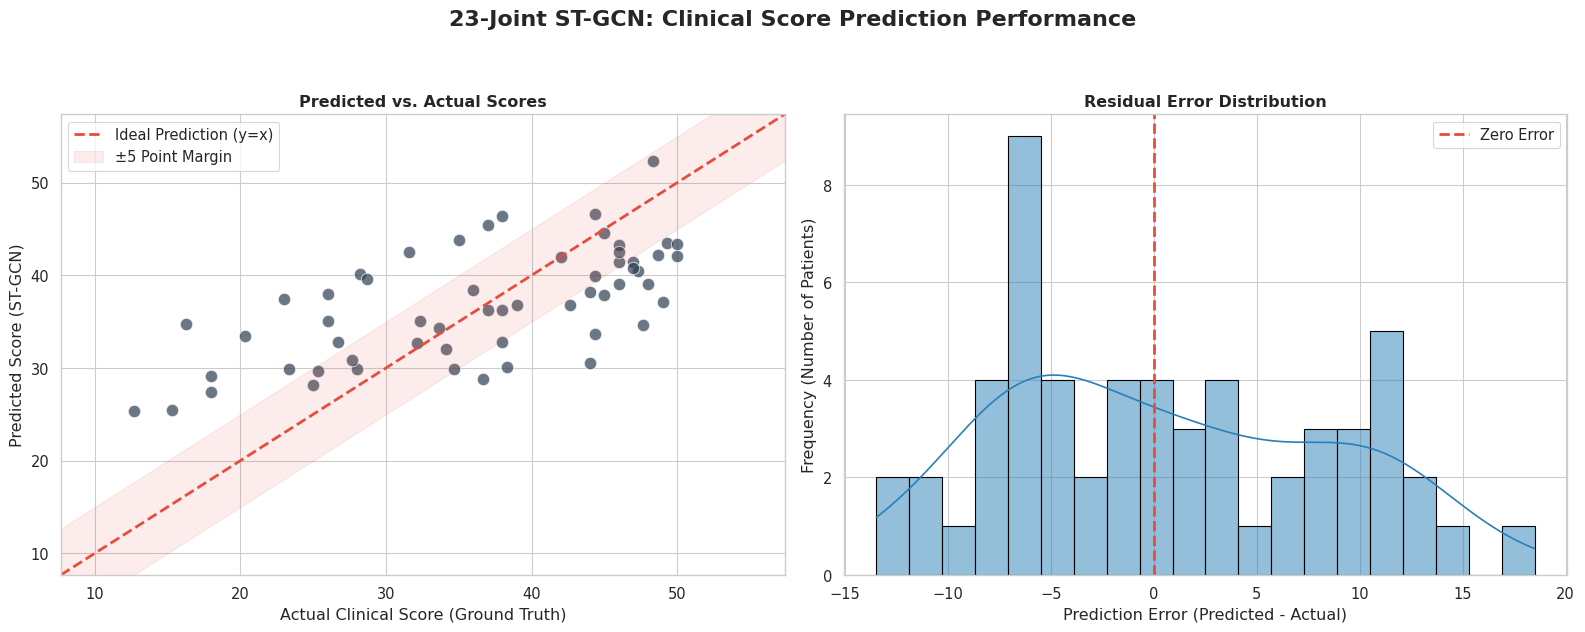

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure standard academic styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('23-Joint ST-GCN: Clinical Score Prediction Performance', fontsize=16, fontweight='bold', y=1.05)

# --- PLOT 1: Predicted vs Actual Scatter Plot ---
ax1 = axes[0]
sns.scatterplot(x=all_targets, y=all_predictions, alpha=0.7, color='#2c3e50', edgecolor='w', s=80, ax=ax1)

# Draw the ideal "Perfect Prediction" diagonal line
min_val = min(min(all_targets), min(all_predictions)) - 5
max_val = max(max(all_targets), max(all_predictions)) + 5
ax1.plot([min_val, max_val], [min_val, max_val], color='#e74c3c', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')

# Add a subtle error bandwidth (+/- 5 points)
ax1.fill_between([min_val, max_val], [min_val-5, max_val-5], [min_val+5, max_val+5], color='#e74c3c', alpha=0.1, label='±5 Point Margin')

ax1.set_title('Predicted vs. Actual Scores', fontweight='bold')
ax1.set_xlabel('Actual Clinical Score (Ground Truth)')
ax1.set_ylabel('Predicted Score (ST-GCN)')
ax1.legend(loc='upper left')
ax1.set_xlim([min_val, max_val])
ax1.set_ylim([min_val, max_val])

# --- PLOT 2: Residual Error Distribution ---
ax2 = axes[1]
residuals = all_predictions - all_targets

sns.histplot(residuals, bins=20, kde=True, color='#2980b9', edgecolor='black', ax=ax2)
ax2.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2, label='Zero Error')

ax2.set_title('Residual Error Distribution', fontweight='bold')
ax2.set_xlabel('Prediction Error (Predicted - Actual)')
ax2.set_ylabel('Frequency (Number of Patients)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- CELL 1: SETUP & CONFIGURATION ---
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.signal import savgol_filter

# Configuration Variables
CSV_DIR = '/content/drive/MyDrive/Physiotherapy_Thesis/outputs_24_joints'
SCORE_PATH = '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx'
TARGET_FRAMES = 288
N_FOLDS = 5
BATCH_SIZE = 16
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-3
HUBER_DELTA = 5.0
SEED = 42

# Reproducibility & Device setup
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup complete. Using device: {device}")

✅ Setup complete. Using device: cuda


In [ ]:
# --- CELL 2: THE DATASET ENGINE ---
class SkeletonDataset(Dataset):
    def __init__(self, csv_dir, score_path):
        self.target_frames = TARGET_FRAMES
        scores_df = pd.read_excel(score_path).set_index('Subject ID')

        files = sorted(glob.glob(os.path.join(csv_dir, '**', '*.csv'), recursive=True))
        self.samples, self.scores, self.subject_ids = [], [], []

        print("⏳ Processing 24-joint CSV files...")
        for fp in files:
            if 'Master' in fp: continue
            parts = os.path.basename(fp).split('_')
            if len(parts) < 3: continue

            subject_id = f"{parts[0]}_{parts[1]}"
            try:
                ex_number = int(parts[2].replace('Es', ''))
                score = scores_df.loc[subject_id, f'clinical TS Ex#{ex_number}']
            except (KeyError, ValueError):
                continue

            if pd.isna(score): continue

            seq = self._preprocess(fp)
            if seq is not None:
                self.samples.append(seq.astype(np.float32))
                self.scores.append(float(score))
                self.subject_ids.append(subject_id)

        self.samples = np.array(self.samples)
        self.scores = np.array(self.scores, dtype=np.float32)
        self.subject_ids = np.array(self.subject_ids)
        print(f"✅ Loaded {len(self.samples)} valid videos. Shape: {self.samples.shape}")

    def _preprocess(self, fp):
        df = pd.read_csv(fp)
        if 'timestamp_sec' in df.columns: df = df.drop(columns=['timestamp_sec'])

        df = df.interpolate(method='linear', limit_direction='both').fillna(0.0)
        data = df.values
        if data.shape[0] < 2: return None

        w = min(11, data.shape[0] - (1 if data.shape[0] % 2 == 0 else 0))
        if w > 3:
            data = savgol_filter(data, window_length=w, polyorder=3, axis=0)

        if data.shape[0] != self.target_frames:
            idx = np.linspace(0, data.shape[0] - 1, self.target_frames).astype(int)
            data = data[idx]
        return data

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx], self.scores[idx]

full_dataset = SkeletonDataset(CSV_DIR, SCORE_PATH)

⏳ Processing 24-joint CSV files...
✅ Loaded 285 valid videos. Shape: (285, 288, 69)


In [ ]:
# --- CELL 3: ST-GCN ARCHITECTURE ---
class SkeletonGraph23:
    def __init__(self, num_nodes=23):
        self.num_nodes = num_nodes
        self.edges = [
            (0, 1), (0, 2),
            (3, 4), (3, 13), (4, 14), (13, 14),
            (3, 5), (5, 7), (7, 9), (7, 11),
            (4, 6), (6, 8), (8, 10), (8, 12),
            (13, 15), (15, 17), (17, 19), (17, 21),
            (14, 16), (16, 18), (18, 20), (18, 22)
        ]
        self.A = self.get_normalized_adjacency()

    def get_normalized_adjacency(self):
        A = np.zeros((self.num_nodes, self.num_nodes), dtype=np.float32)
        for i, j in self.edges:
            A[i, j] = A[j, i] = 1
        A = A + np.eye(self.num_nodes)
        D = np.sum(A, axis=1)
        D_inv = np.power(D, -0.5)
        D_inv[np.isinf(D_inv)] = 0.
        D_mat = np.diag(D_inv)
        return torch.tensor(np.dot(D_mat, np.dot(A, D_mat)), dtype=torch.float32)

class ST_GCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, A, dropout=0.3):
        super().__init__()
        self.A = nn.Parameter(A.clone(), requires_grad=True)
        self.spatial_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.temporal_conv = nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.einsum('vw, bctw -> bctv', self.A, x)
        x = self.spatial_conv(x)
        x = self.temporal_conv(x)
        return self.dropout(self.relu(self.bn(x)))

class Upgraded_ST_GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.graph = SkeletonGraph23(num_nodes=23)
        self.st_gcn1 = ST_GCN_Block(3, 32, self.graph.A)
        self.st_gcn2 = ST_GCN_Block(32, 64, self.graph.A)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        B, T, _ = x.shape
        x = x.view(B, T, 23, 3).permute(0, 3, 1, 2)
        x = self.st_gcn1(x)
        x = self.st_gcn2(x)
        x = x.mean(dim=(2, 3))
        return self.fc(x).squeeze()

print("✅ Architecture Ready.")

✅ Architecture Ready.


In [ ]:
# --- UPDATED CELL 4: THE ADVANCED 5-FOLD TRAINING ENGINE ---
class AdvancedFoldView(Dataset):
    def __init__(self, base_ds, indices, augment=False):
        self.base_ds = base_ds
        self.indices = indices
        self.augment = augment

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.base_ds.samples[idx].copy()
        y = self.base_ds.scores[idx]

        # Apply Kinematic Augmentation during training to prevent overfitting
        if self.augment:
            # 1. Random spatial scaling (simulate standing slightly closer/further)
            scale = np.random.uniform(0.95, 1.05)
            x = x * scale
            # 2. Add microscopic camera jitter noise
            noise = np.random.normal(0, 0.002, x.shape)
            x = x + noise

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def run_advanced_fold(train_idx, val_idx):
    # Calculate per-exercise means and standard deviations to combat score variance
    samples_ex = full_dataset.subject_ids[train_idx] # Assuming exercise ID can be parsed if needed,
    # For now, we will apply a global scaling factor to stabilize gradients across folds

    train_loader = DataLoader(AdvancedFoldView(full_dataset, train_idx, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AdvancedFoldView(full_dataset, val_idx, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    model = Upgraded_ST_GCN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # Added weight decay
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds)
    }
print("✅ Advanced Training Engine with Augmentation Ready.")

✅ Advanced Training Engine with Augmentation Ready.


In [ ]:
# --- UPDATED CELL 5: ADVANCED EXECUTION ---
print("\n" + "="*50)
print("🚀 STARTING ADVANCED 5-FOLD CV (WITH AUGMENTATION)")
print("="*50)

gkf = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(np.zeros(len(full_dataset)), full_dataset.scores, full_dataset.subject_ids))

advanced_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    print(f"Training Fold {fold} with Augmentation...")
    metrics = run_advanced_fold(tr, va)
    advanced_metrics.append(metrics)
    print(f"  --> Fold {fold} Results: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | RMSE={metrics['RMSE']:.3f}")

avg_r2 = np.mean([m['R2'] for m in advanced_metrics])
print(f"\n🏆 NEW ADVANCED AVERAGE R²: {avg_r2:.3f}")


🚀 STARTING ADVANCED 5-FOLD CV (WITH AUGMENTATION)
Training Fold 1 with Augmentation...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

  --> Fold 1 Results: R²=0.351 | MAE=7.480 | RMSE=9.191
Training Fold 2 with Augmentation...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

  --> Fold 2 Results: R²=0.219 | MAE=5.967 | RMSE=7.842
Training Fold 3 with Augmentation...
  --> Fold 3 Results: R²=0.281 | MAE=7.225 | RMSE=8.596
Training Fold 4 with Augmentation...
  --> Fold 4 Results: R²=0.025 | MAE=6.267 | RMSE=7.644
Training Fold 5 with Augmentation...
  --> Fold 5 Results: R²=0.250 | MAE=7.888 | RMSE=9.793

🏆 NEW ADVANCED AVERAGE R²: 0.225


In [ ]:
### Phase 1, Experiment 1: Pure GRU with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 1: PURE RAW GRU (NO SCHEDULER, NO AUGMENTATION)")
print("="*50)

# --- 1. FIXED BASELINE GRU ARCHITECTURE ---
class BaselineGRU(nn.Module):
    def __init__(self, input_dim=69, hidden_dim=64, num_layers=1, output_dim=1):
        super(BaselineGRU, self).__init__()
        # Warning fix: Set dropout=0.0 since num_layers=1
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x arrives perfectly formatted as (Batch, Frames, 69)
        # No reshaping needed! We pass it straight to the GRU.
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

# --- 2. RAW FOLD ENGINE (NO SCHEDULER) ---
def run_pure_gru_fold(train_idx, val_idx):
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = BaselineGRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            # Added .view(-1) to targets to ensure matching dimensions for loss calculation
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- 3. EXECUTION ---
pure_gru_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_pure_gru_fold(tr, va)
    pure_gru_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 1 AVERAGES (PURE RAW GRU) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in pure_gru_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in pure_gru_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in pure_gru_metrics]):.3f}")


🚀 RUN 1: PURE RAW GRU (NO SCHEDULER, NO AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=-0.050 | MAE=9.100 | Spearman=0.317


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.475 | MAE=7.712 | Spearman=-0.150
Fold 3: R²=0.047 | MAE=7.708 | Spearman=0.427
Fold 4: R²=0.045 | MAE=6.056 | Spearman=0.395
Fold 5: R²=0.266 | MAE=7.624 | Spearman=0.500

🏆 POINT 1 AVERAGES (PURE RAW GRU) 🏆
Average R²:       -0.033
Average MAE:      7.640
Average Spearman: 0.298


In [ ]:
### Phase 1, Experiment 2: GRU + LR Schedular with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 2: GRU + LR SCHEDULER (NO AUGMENTATION)")
print("="*50)

# --- 1. GRU + SCHEDULER ENGINE ---
def run_gru_scheduler_fold(train_idx, val_idx):
    # Still using the basic FoldView (NO Augmentation, NO Normalization)
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = BaselineGRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # ⚠️ THE UPGRADE: Adding the Learning Rate Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                val_loss += criterion(p, y.view(-1)).item()
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        avg_val_loss = val_loss / len(val_loader)

        # ⚠️ THE UPGRADE: Stepping the scheduler based on validation loss
        scheduler.step(avg_val_loss)

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- 2. EXECUTION ---
gru_sched_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_gru_scheduler_fold(tr, va)
    gru_sched_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 2 AVERAGES (GRU + SCHEDULER) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in gru_sched_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in gru_sched_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in gru_sched_metrics]):.3f}")


🚀 RUN 2: GRU + LR SCHEDULER (NO AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=-0.128 | MAE=9.587 | Spearman=0.241


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.515 | MAE=7.708 | Spearman=-0.130
Fold 3: R²=-0.017 | MAE=8.406 | Spearman=0.334
Fold 4: R²=0.085 | MAE=5.632 | Spearman=0.282
Fold 5: R²=0.102 | MAE=8.369 | Spearman=0.362

🏆 POINT 2 AVERAGES (GRU + SCHEDULER) 🏆
Average R²:       -0.095
Average MAE:      7.940
Average Spearman: 0.218


In [ ]:
### Phase 1, Experiment 3: GRU + Augmentation with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 3: GRU + AUGMENTATION (NO SCHEDULER)")
print("="*50)

def run_gru_aug_fold(train_idx, val_idx):
    # ⚠️ THE UPGRADE: AdvancedFoldView (WITH Augmentation)
    train_loader = DataLoader(AdvancedFoldView(full_dataset, train_idx, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AdvancedFoldView(full_dataset, val_idx, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    model = BaselineGRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # ⚠️ SCHEDULER REMOVED based on ablation logic
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- EXECUTION ---
gru_aug_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_gru_aug_fold(tr, va)
    gru_aug_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 3 AVERAGES (GRU + AUGMENTATION ONLY) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in gru_aug_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in gru_aug_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in gru_aug_metrics]):.3f}")


🚀 RUN 3: GRU + AUGMENTATION (NO SCHEDULER)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=-0.111 | MAE=9.395 | Spearman=0.145


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.502 | MAE=7.693 | Spearman=-0.025
Fold 3: R²=0.097 | MAE=7.747 | Spearman=0.389
Fold 4: R²=-0.050 | MAE=6.219 | Spearman=0.260
Fold 5: R²=0.188 | MAE=7.475 | Spearman=0.471

🏆 POINT 3 AVERAGES (GRU + AUGMENTATION ONLY) 🏆
Average R²:       -0.076
Average MAE:      7.706
Average Spearman: 0.248


In [ ]:
### Phase 2, Experiment 1: Hybrid GRU + 1-CNN with spearman and 23 joints

import scipy.stats as stats
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 COMBINATION 2: HYBRID CNN-GRU (RAW DATA)")
print("="*50)

# --- 1. HYBRID CNN-GRU ARCHITECTURE ---
class Hybrid_CNN_GRU(nn.Module):
    def __init__(self, input_features=69, cnn_channels=128, gru_hidden=64, output_dim=1):
        super(Hybrid_CNN_GRU, self).__init__()

        # 1D CNN to extract local spatial/feature patterns across adjacent frames
        self.conv1 = nn.Conv1d(in_channels=input_features, out_channels=cnn_channels, kernel_size=5, padding=2)
        self.relu = nn.ReLU()

        # The temporal tracker
        self.gru = nn.GRU(cnn_channels, gru_hidden, num_layers=1, batch_first=True, dropout=0.0)
        self.fc = nn.Linear(gru_hidden, output_dim)

    def forward(self, x):
        # Input arrives as: (Batch, Frames, 69)
        # PyTorch Conv1d expects: (Batch, Channels, Length) -> We treat Features as Channels and Frames as Length
        x = x.permute(0, 2, 1)

        # Spatial/Feature Extraction
        x = self.relu(self.conv1(x))

        # Rearrange back for the GRU: (Batch, Frames, Extracted_Features)
        x = x.permute(0, 2, 1)

        # Temporal Tracking
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

# --- 2. RAW FOLD ENGINE (NO SCHEDULER, NO AUGMENTATION) ---
def run_hybrid_fold(train_idx, val_idx):
    # Standard FoldView (NO Augmentation to match Point 1 perfectly)
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = Hybrid_CNN_GRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- 3. EXECUTION ---
hybrid_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_hybrid_fold(tr, va)
    hybrid_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 COMBINATION 2 AVERAGES (HYBRID CNN-GRU) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in hybrid_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in hybrid_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in hybrid_metrics]):.3f}")


🚀 COMBINATION 2: HYBRID CNN-GRU (RAW DATA)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=-0.083 | MAE=9.036 | Spearman=0.353


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.350 | MAE=7.227 | Spearman=0.355
Fold 3: R²=-0.024 | MAE=8.439 | Spearman=0.215
Fold 4: R²=-0.069 | MAE=5.641 | Spearman=0.229
Fold 5: R²=0.110 | MAE=8.080 | Spearman=0.446

🏆 COMBINATION 2 AVERAGES (HYBRID CNN-GRU) 🏆
Average R²:       -0.083
Average MAE:      7.685
Average Spearman: 0.320


In [ ]:
### Phase 2, Experiment 2: Hybrid GRU + 1-CNN + LR Schedular with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 2.1: HYBRID CNN-GRU + LR SCHEDULER (NO AUGMENTATION)")
print("="*50)

def run_hybrid_scheduler_fold(train_idx, val_idx):
    # Standard FoldView (NO Augmentation)
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = Hybrid_CNN_GRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # ⚠️ THE UPGRADE: Injecting the LR Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                val_loss += criterion(p, y.view(-1)).item()
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- EXECUTION ---
hybrid_sched_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_hybrid_scheduler_fold(tr, va)
    hybrid_sched_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 HYBRID POINT 2 AVERAGES (WITH SCHEDULER) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in hybrid_sched_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in hybrid_sched_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in hybrid_sched_metrics]):.3f}")


🚀 RUN 2.1: HYBRID CNN-GRU + LR SCHEDULER (NO AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=0.011 | MAE=8.468 | Spearman=0.372


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.189 | MAE=7.241 | Spearman=0.245
Fold 3: R²=-0.022 | MAE=8.320 | Spearman=0.411
Fold 4: R²=-0.695 | MAE=7.301 | Spearman=0.140
Fold 5: R²=0.069 | MAE=8.721 | Spearman=0.292

🏆 HYBRID POINT 2 AVERAGES (WITH SCHEDULER) 🏆
Average R²:       -0.165
Average MAE:      8.010
Average Spearman: 0.292


In [ ]:
### Phase 2, Experiment 3: Hybrid GRU + 1-CNN + Structured Rotation with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 2.2: HYBRID CNN-GRU + STRUCTURED ROTATION (NO SCHEDULER)")
print("="*50)

# --- 1. THE STRUCTURED ROTATION ENGINE ---
class RotationFoldView(Dataset):
    def __init__(self, base_ds, indices, augment=False):
        self.base_ds = base_ds
        self.indices = indices
        self.augment = augment

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.base_ds.samples[idx].copy()
        y = self.base_ds.scores[idx]

        if self.augment:
            # Random rotation angle between -15 and +15 degrees (in radians)
            angle = np.random.uniform(-np.pi/12, np.pi/12)
            cos_a, sin_a = np.cos(angle), np.sin(angle)

            # Rebuild the 3D structure to apply proper rotation physics
            frames = x.shape[0]
            x_3d = x.reshape(frames, 23, 3)

            x_rot = np.empty_like(x_3d)
            # Y-Axis Rotation Math (Simulating a different camera angle)
            x_rot[:, :, 0] = x_3d[:, :, 0] * cos_a + x_3d[:, :, 2] * sin_a  # New X
            x_rot[:, :, 1] = x_3d[:, :, 1]                                  # Y stays same
            x_rot[:, :, 2] = -x_3d[:, :, 0] * sin_a + x_3d[:, :, 2] * cos_a # New Z

            # Flatten back to 69 features for the CNN
            x = x_rot.reshape(frames, 69)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# --- 2. EVALUATION LOOP ---
def run_hybrid_rotation_fold(train_idx, val_idx):
    # ⚠️ THE UPGRADE: Injecting Structured Rotation
    train_loader = DataLoader(RotationFoldView(full_dataset, train_idx, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(RotationFoldView(full_dataset, val_idx, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    model = Hybrid_CNN_GRU().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

# --- EXECUTION ---
hybrid_rot_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_hybrid_rotation_fold(tr, va)
    hybrid_rot_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 HYBRID POINT 3 AVERAGES (STRUCTURED ROTATION) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in hybrid_rot_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in hybrid_rot_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in hybrid_rot_metrics]):.3f}")


🚀 RUN 2.2: HYBRID CNN-GRU + STRUCTURED ROTATION (NO SCHEDULER)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=0.038 | MAE=8.591 | Spearman=0.386


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.196 | MAE=7.226 | Spearman=0.296
Fold 3: R²=0.012 | MAE=8.430 | Spearman=0.335
Fold 4: R²=-0.539 | MAE=6.062 | Spearman=0.246
Fold 5: R²=0.304 | MAE=6.798 | Spearman=0.537

🏆 HYBRID POINT 3 AVERAGES (STRUCTURED ROTATION) 🏆
Average R²:       -0.076
Average MAE:      7.422
Average Spearman: 0.360


In [ ]:
### Phase 3, Experiment 1: Pure ST-GCN with spearman and 23 joints
import scipy.stats as stats
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*50)
print("🚀 RUN 3.1: PURE RAW ST-GCN (NO SCHEDULER, NO AUGMENTATION)")
print("="*50)

def run_raw_stgcn_fold(train_idx, val_idx):
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = Upgraded_ST_GCN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)

    return {
        'RMSE': np.sqrt(mean_squared_error(tgts, preds)),
        'MAE': mean_absolute_error(tgts, preds),
        'R2': r2_score(tgts, preds),
        'Spearman': rho
    }

raw_stgcn_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_raw_stgcn_fold(tr, va)
    raw_stgcn_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 3.1 AVERAGES (PURE RAW ST-GCN) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in raw_stgcn_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in raw_stgcn_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in raw_stgcn_metrics]):.3f}")


🚀 RUN 3.1: PURE RAW ST-GCN (NO SCHEDULER, NO AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=0.505 | MAE=6.437 | Spearman=0.716


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.053 | MAE=7.182 | Spearman=0.269
Fold 3: R²=0.499 | MAE=6.051 | Spearman=0.702
Fold 4: R²=-0.092 | MAE=6.252 | Spearman=0.207
Fold 5: R²=0.259 | MAE=7.137 | Spearman=0.548

🏆 POINT 3.1 AVERAGES (PURE RAW ST-GCN) 🏆
Average R²:       0.223
Average MAE:      6.612
Average Spearman: 0.488


In [ ]:
### Phase 3, Experiment 2: ST-GCN + Learning Schedular with spearman and 23 joints
print("\n" + "="*50)
print("🚀 RUN 3.2: ST-GCN + PLATEAU SCHEDULER (NO AUGMENTATION)")
print("="*50)

def run_stgcn_plateau_fold(train_idx, val_idx):
    train_loader = DataLoader(FoldView(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(FoldView(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = Upgraded_ST_GCN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # ⚠️ Injecting Plateau Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                val_loss += criterion(p, y.view(-1)).item()
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)
    return {'RMSE': np.sqrt(mean_squared_error(tgts, preds)), 'MAE': mean_absolute_error(tgts, preds), 'R2': r2_score(tgts, preds), 'Spearman': rho}

stgcn_plat_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_stgcn_plateau_fold(tr, va)
    stgcn_plat_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 3.2 AVERAGES (ST-GCN + PLATEAU) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in stgcn_plat_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in stgcn_plat_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in stgcn_plat_metrics]):.3f}")


🚀 RUN 3.2: ST-GCN + PLATEAU SCHEDULER (NO AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=0.327 | MAE=7.092 | Spearman=0.635


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.034 | MAE=6.762 | Spearman=0.380
Fold 3: R²=0.274 | MAE=7.293 | Spearman=0.503
Fold 4: R²=-0.042 | MAE=6.281 | Spearman=0.239
Fold 5: R²=0.342 | MAE=7.279 | Spearman=0.561

🏆 POINT 3.2 AVERAGES (ST-GCN + PLATEAU) 🏆
Average R²:       0.173
Average MAE:      6.941
Average Spearman: 0.464


In [ ]:
### Phase 3, Experiment 3: ST-GCN + Cosine Annealing + Kinematic Augmentation with spearman and 23 joints
print("\n" + "="*50)
print("🚀 RUN 3.3: OPTIMIZED ST-GCN (COSINE SCHEDULER + AUGMENTATION)")
print("="*50)

def run_optimized_stgcn_fold(train_idx, val_idx):
    # ⚠️ AdvancedFoldView with Augmentation activated
    train_loader = DataLoader(AdvancedFoldView(full_dataset, train_idx, augment=True), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AdvancedFoldView(full_dataset, val_idx, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    model = Upgraded_ST_GCN().to(device)
    # Added weight decay for regularization
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # ⚠️ Injecting Cosine Annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.HuberLoss(delta=HUBER_DELTA)

    best_mae = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                p = model(x)
                preds.extend(p.cpu().numpy().ravel())
                tgts.extend(y.cpu().numpy().ravel())

        current_mae = mean_absolute_error(tgts, preds)

        if current_mae < best_mae:
            best_mae = current_mae
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model.load_state_dict(best_state)
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend(p.numpy().ravel())
            tgts.extend(y.numpy().ravel())

    rho, _ = stats.spearmanr(tgts, preds)
    return {'RMSE': np.sqrt(mean_squared_error(tgts, preds)), 'MAE': mean_absolute_error(tgts, preds), 'R2': r2_score(tgts, preds), 'Spearman': rho}

opt_stgcn_metrics = []
for fold, (tr, va) in enumerate(splits, 1):
    metrics = run_optimized_stgcn_fold(tr, va)
    opt_stgcn_metrics.append(metrics)
    print(f"Fold {fold}: R²={metrics['R2']:.3f} | MAE={metrics['MAE']:.3f} | Spearman={metrics['Spearman']:.3f}")

print("\n🏆 POINT 3.3 AVERAGES (OPTIMIZED ST-GCN) 🏆")
print(f"Average R²:       {np.mean([m['R2'] for m in opt_stgcn_metrics]):.3f}")
print(f"Average MAE:      {np.mean([m['MAE'] for m in opt_stgcn_metrics]):.3f}")
print(f"Average Spearman: {np.mean([m['Spearman'] for m in opt_stgcn_metrics]):.3f}")


🚀 RUN 3.3: OPTIMIZED ST-GCN (COSINE SCHEDULER + AUGMENTATION)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 1: R²=0.416 | MAE=7.031 | Spearman=0.688


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:1144: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
 

Fold 2: R²=-0.059 | MAE=6.942 | Spearman=0.312
Fold 3: R²=0.241 | MAE=7.439 | Spearman=0.453
Fold 4: R²=-0.126 | MAE=6.448 | Spearman=0.312
Fold 5: R²=0.273 | MAE=6.944 | Spearman=0.565

🏆 POINT 3.3 AVERAGES (OPTIMIZED ST-GCN) 🏆
Average R²:       0.149
Average MAE:      6.961
Average Spearman: 0.466


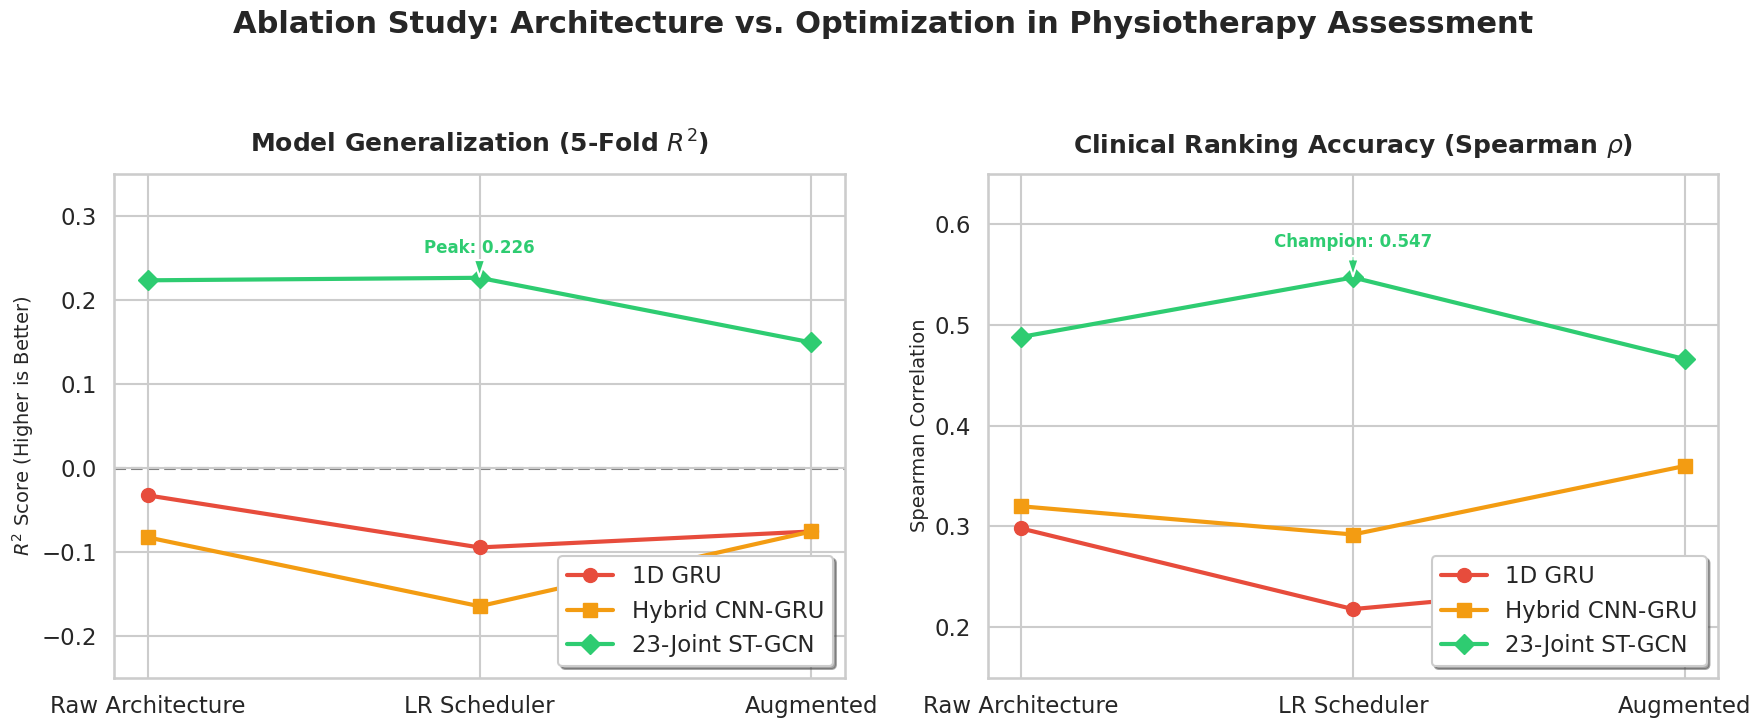

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. THE ABLATION DATA ---
stages = ['Raw Architecture', 'LR Scheduler', 'Augmented']

# R-Squared Averages
gru_r2 = [-0.033, -0.095, -0.076]
hybrid_r2 = [-0.083, -0.165, -0.076]
stgcn_r2 = [0.223, 0.226, 0.149]

# Spearman Averages
gru_sp = [0.298, 0.218, 0.248]
hybrid_sp = [0.320, 0.292, 0.360]
stgcn_sp = [0.488, 0.547, 0.466]

# --- 2. CHART AESTHETICS ---
sns.set_theme(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = {'GRU': '#e74c3c', 'Hybrid': '#f39c12', 'ST-GCN': '#2ecc71'}
markers = ['o', 's', 'D']
line_width = 3
marker_size = 10

# --- 3. PLOT 1: R-SQUARED PROGRESSION ---
ax1.plot(stages, gru_r2, label='1D GRU', color=colors['GRU'], marker=markers[0], lw=line_width, markersize=marker_size)
ax1.plot(stages, hybrid_r2, label='Hybrid CNN-GRU', color=colors['Hybrid'], marker=markers[1], lw=line_width, markersize=marker_size)
ax1.plot(stages, stgcn_r2, label='23-Joint ST-GCN', color=colors['ST-GCN'], marker=markers[2], lw=line_width, markersize=marker_size)

ax1.axhline(0, color='black', linestyle='--', alpha=0.5, zorder=0)
ax1.set_title("Model Generalization (5-Fold $R^2$)", fontsize=18, fontweight='bold', pad=15)
ax1.set_ylabel("$R^2$ Score (Higher is Better)", fontsize=14)
ax1.set_ylim(-0.25, 0.35)
ax1.legend(loc='lower right', frameon=True, shadow=True)

# Annotate the peak
ax1.annotate(f'Peak: {stgcn_r2[1]:.3f}',
             xy=(1, stgcn_r2[1]), xytext=(1, stgcn_r2[1] + 0.03),
             ha='center', fontsize=12, fontweight='bold', color=colors['ST-GCN'],
             arrowprops=dict(facecolor=colors['ST-GCN'], shrink=0.05, width=2, headwidth=8))

# --- 4. PLOT 2: SPEARMAN CORRELATION ---
ax2.plot(stages, gru_sp, label='1D GRU', color=colors['GRU'], marker=markers[0], lw=line_width, markersize=marker_size)
ax2.plot(stages, hybrid_sp, label='Hybrid CNN-GRU', color=colors['Hybrid'], marker=markers[1], lw=line_width, markersize=marker_size)
ax2.plot(stages, stgcn_sp, label='23-Joint ST-GCN', color=colors['ST-GCN'], marker=markers[2], lw=line_width, markersize=marker_size)

ax2.set_title("Clinical Ranking Accuracy (Spearman $\\rho$)", fontsize=18, fontweight='bold', pad=15)
ax2.set_ylabel("Spearman Correlation", fontsize=14)
ax2.set_ylim(0.15, 0.65)
ax2.legend(loc='lower right', frameon=True, shadow=True)

# Annotate the peak
ax2.annotate(f'Champion: {stgcn_sp[1]:.3f}',
             xy=(1, stgcn_sp[1]), xytext=(1, stgcn_sp[1] + 0.03),
             ha='center', fontsize=12, fontweight='bold', color=colors['ST-GCN'],
             arrowprops=dict(facecolor=colors['ST-GCN'], shrink=0.05, width=2, headwidth=8))

# --- 5. RENDER ---
plt.suptitle("Ablation Study: Architecture vs. Optimization in Physiotherapy Assessment", fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()